In [6]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns 

In [8]:
df = pd.read_csv("customer_segmentation.csv")

In [9]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [10]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [11]:
df.shape

(2240, 29)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [13]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [14]:
df.dropna(inplace = True)

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [17]:
df.describe().round(2)

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,...,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.0,2216.0,2216.00
mean,5588.35,1968.82,52247.25,0.44,0.51,49.01,305.09,26.36,167.00,37.64,...,5.32,0.07,0.07,0.07,0.06,0.01,0.01,3.0,11.0,0.15
std,3249.38,11.99,25173.08,0.54,0.54,28.95,337.33,39.79,224.28,54.75,...,2.43,0.26,0.26,0.26,0.24,0.12,0.10,0.0,0.0,0.36
min,0.00,1893.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
25%,2814.75,1959.00,35303.00,0.00,0.00,24.00,24.00,2.00,16.00,3.00,...,3.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
50%,5458.50,1970.00,51381.50,0.00,0.00,49.00,174.50,8.00,68.00,12.00,...,6.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
75%,8421.75,1977.00,68522.00,1.00,1.00,74.00,505.00,33.00,232.25,50.00,...,7.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
max,11191.00,1996.00,666666.00,2.00,2.00,99.00,1493.00,199.00,1725.00,259.00,...,20.00,1.00,1.00,1.00,1.00,1.00,1.00,3.0,11.0,1.00


In [18]:
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [19]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [20]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],dayfirst = True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [22]:
df['Age'] = 2025 - df['Year_Birth']

In [23]:
df['Age'].head()

0    68
1    71
2    60
3    41
4    44
Name: Age, dtype: int64

In [24]:
df.head(2)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,68
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,71


In [25]:
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [27]:
df['Total_Children'].head()

0    0
1    2
2    0
3    1
4    1
Name: Total_Children, dtype: int64

In [28]:
spend_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']

In [29]:
df['Total_Spending'] = df[spend_cols].sum(axis = 1)

In [30]:
df['Total_Spending'].head(10)

0    1617
1      27
2     776
3      53
4     422
5     716
6     590
7     169
8      46
9      49
Name: Total_Spending, dtype: int64

In [31]:
df['Customer_Since'] = (pd.Timestamp('today')-df['Dt_Customer']).dt.days

In [32]:
df['Customer_Since'].head()

0    4946
1    4396
2    4595
3    4422
4    4444
Name: Customer_Since, dtype: int64

In [33]:
print(df.duplicated().sum())

0


EDA

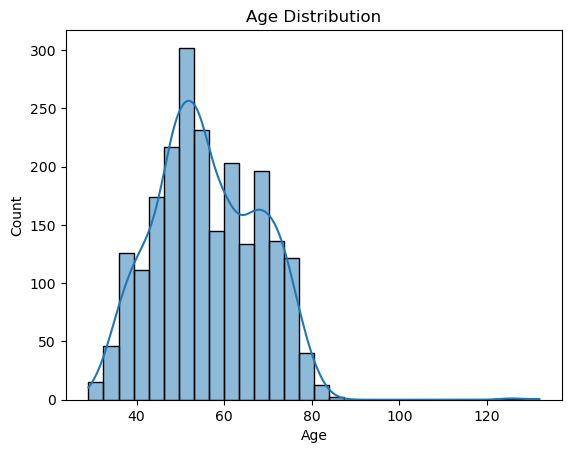

In [34]:
sns.histplot(df['Age'],bins=30,kde=True)
plt.title('Age Distribution')
plt.show()

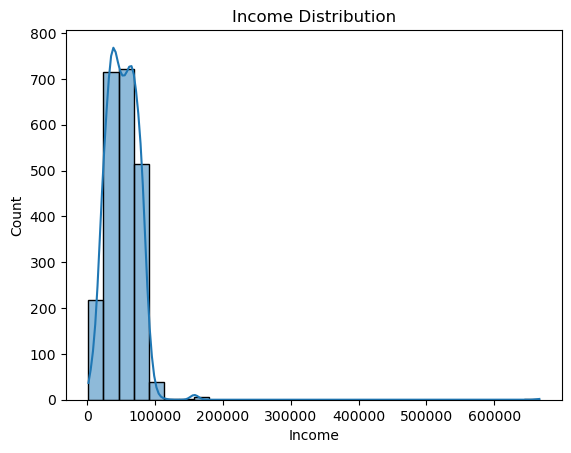

In [37]:
sns.histplot(df['Income'],bins = 30,kde = True)
plt.title('Income Distribution')
plt.show()

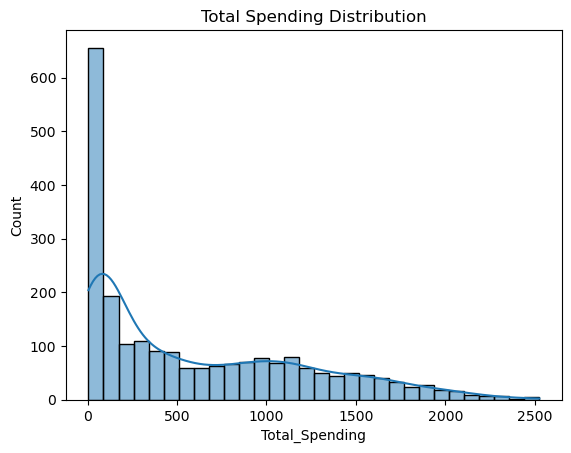

In [38]:
sns.histplot(df['Total_Spending'],bins = 30 , kde = True)
plt.title('Total Spending Distribution')
plt.show()

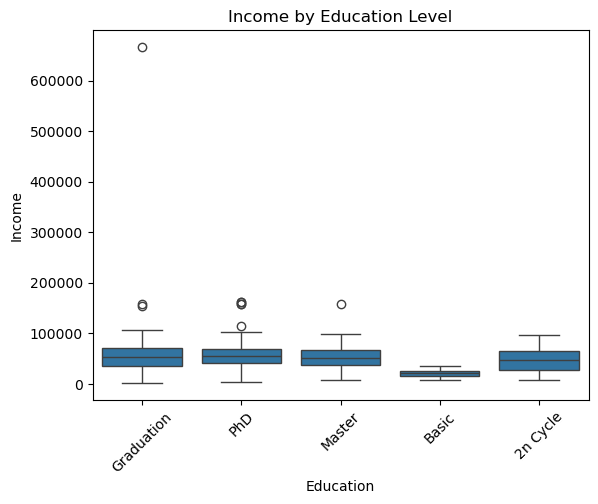

In [39]:
sns.boxplot(x='Education',y='Income',data = df)
plt.xticks(rotation = 45)
plt.title('Income by Education Level')
plt.show()

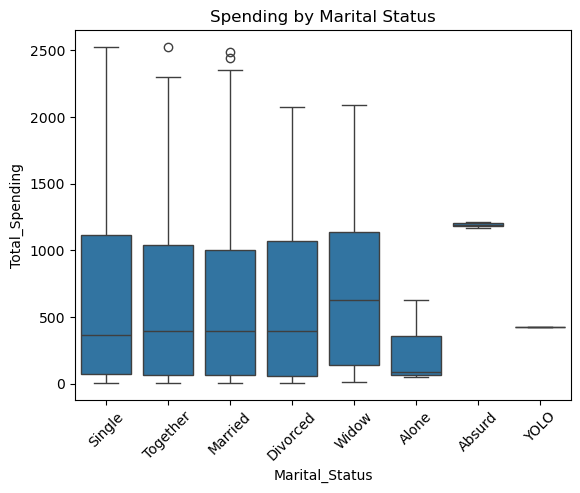

In [40]:
sns.boxplot(x='Marital_Status',y='Total_Spending',data=df)
plt.xticks(rotation = 45)
plt.title('Spending by Marital Status')
plt.show()

In [41]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since'],
      dtype='object')

In [47]:
corr = df[['Income','Age','Recency','Total_Spending','NumWebPurchases','NumStorePurchases']].corr()

In [48]:
corr.head()

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.113487,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.020066,-0.005641,-0.000434
Total_Spending,0.667576,0.113487,0.020066,1.000000,0.528973,0.675181
NumWebPurchases,0.387878,0.153051,-0.005641,0.528973,1.000000,0.516240


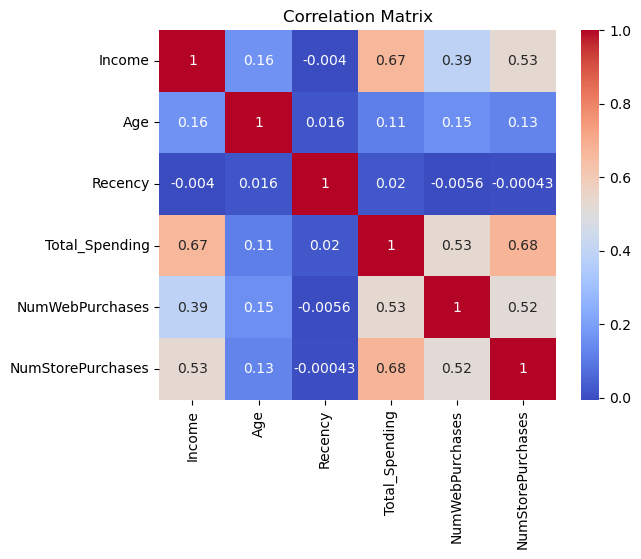

In [49]:
sns.heatmap(corr,annot = True,cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [50]:
pivot_income =  df.pivot_table(values = 'Income',index = 'Education',columns = 'Marital_Status',aggfunc = 'mean')

In [52]:
pivot_income.round(2)

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.13,46201.10,53673.94,44736.41,51392.20,NaN
Basic,NaN,NaN,9548.00,21960.50,18238.67,21240.07,22123.00,NaN
Graduation,79244.0,34176.0,54526.04,50800.26,51322.18,55758.48,54976.66,NaN
Master,65487.0,61331.0,50331.95,53286.03,53530.56,52109.01,58401.55,NaN
PhD,NaN,35860.0,53096.62,58138.03,53314.61,56041.42,60288.08,48432.0


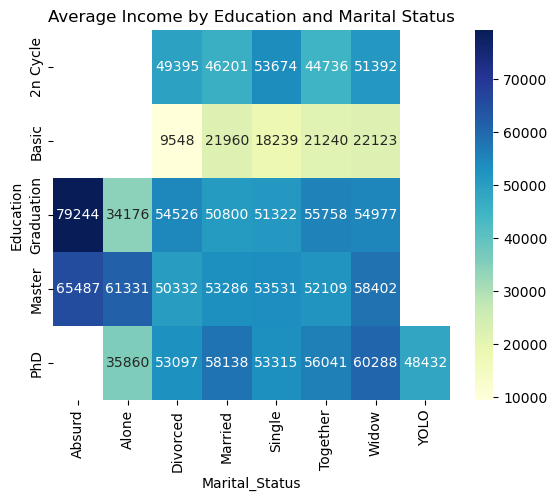

In [55]:
sns.heatmap(pivot_income,annot = True,fmt = '.0f',cmap = 'YlGnBu')
plt.title('Average Income by Education and Marital Status')
plt.show()

In [56]:
group1 = df.groupby('Education')['Total_Spending'].mean().sort_values(ascending = False)

In [58]:
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

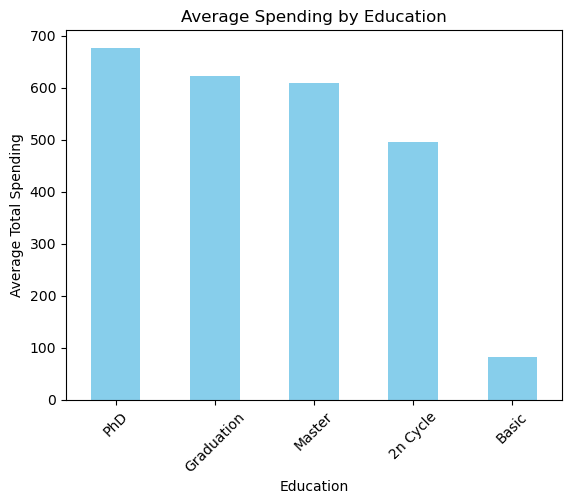

In [62]:
group1.plot(kind = 'bar',color = 'skyblue')
plt.title('Average Spending by Education')
plt.ylabel('Average Total Spending')
plt.xticks(rotation = 45)
plt.show()

In [65]:
df['AcceptedAny'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis = 1)

In [67]:
df['AcceptedAny'].unique()

array([1, 0, 3, 2, 4, 5])

In [68]:
df['AcceptedAny'] = df['AcceptedAny'].apply(lambda x : 1 if x>0 else 0)

In [69]:
df['AcceptedAny'].unique()

array([1, 0])

In [71]:
group2 = df.groupby('Marital_Status')['AcceptedAny'].mean().sort_values(ascending = False)

In [72]:
group2.head

<bound method NDFrame.head of Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64>

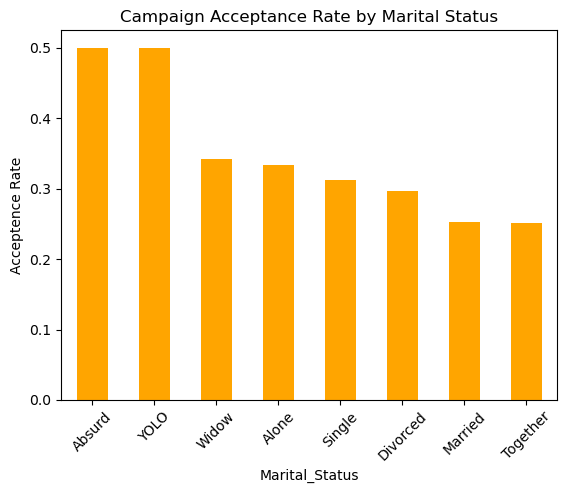

In [73]:
group2.plot(kind = 'bar', color = 'orange')
plt.title("Campaign Acceptance Rate by Marital Status")
plt.ylabel('Acceptence Rate')
plt.xticks(rotation = 45)
plt.show()

In [74]:
bins = [18,30,40,50,60,70,90]

In [79]:
labels = ['18-29','30-39','40-49','50-59','60-69','70+']

In [80]:
df['AgeGroup'] = pd.cut(df['Age'],bins = bins,labels = labels)

In [82]:
df['AgeGroup'].head()

0    60-69
1      70+
2    50-59
3    40-49
4    40-49
Name: AgeGroup, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [83]:
group3 = df.groupby('AgeGroup')['Income'].mean()

In [84]:
group3.head()

AgeGroup
18-29    46658.000000
30-39    46283.028302
40-49    49224.877034
50-59    50812.913303
60-69    56200.827887
Name: Income, dtype: float64

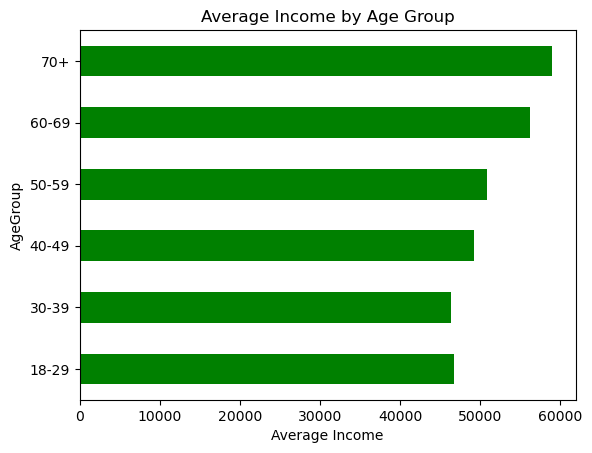

In [85]:
group3.plot(kind = 'barh',color = 'green')
plt.title('Average Income by Age Group')
plt.xlabel('Average Income')
plt.show()

In [86]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,68,0,1617,4946,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,71,2,27,4396,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,60,0,776,4595,0,50-59
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,41,1,53,4422,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,44,1,422,4444,0,40-49


In [87]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

Age- Income - Total_Spending - NumWebPurchases - NumStorePurchases - NumWebVisitsMonth- Recency

In [91]:
Features = ['Age','Income','Total_Spending','NumWebPurchases','NumStorePurchases','NumWebVisitsMonth','Recency']

In [92]:
X = df[Features].copy()

In [93]:
X.head()

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,68,58138.0,1617,8,4,7,58
1,71,46344.0,27,1,2,5,38
2,60,71613.0,776,8,10,4,26
3,41,26646.0,53,2,4,6,26
4,44,58293.0,422,5,6,5,94


In [94]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [95]:
X_scaled  = scaler.fit_transform(X)

In [97]:
X_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]])

In [98]:
from sklearn.cluster import KMeans

In [99]:
wcss = []

In [101]:
for i in range(2,10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [102]:
wcss

[10218.620143748783,
 9007.783808892222,
 8239.362881709398,
 7936.111332046436,
 7131.3781804016435,
 6705.990139608604,
 6413.561667643985,
 5911.525557992165]

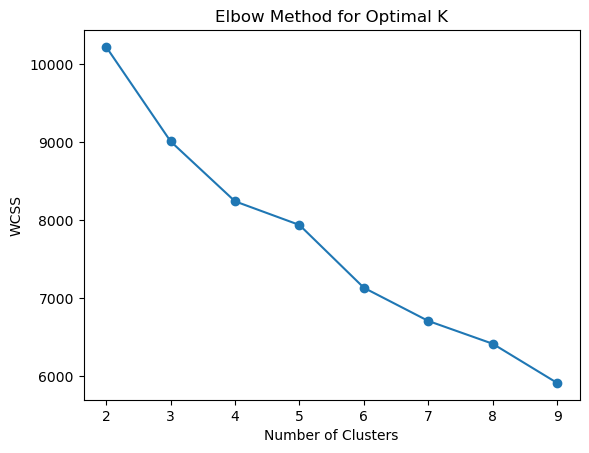

In [103]:
plt.plot(range(2,10),wcss,marker = 'o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [105]:
kmeans = KMeans(n_clusters = 6)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [106]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,68,0,1617,4946,1,60-69,4
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,71,2,27,4396,0,70+,1
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,60,0,776,4595,0,50-59,4
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,41,1,53,4422,0,40-49,3
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,44,1,422,4444,0,40-49,0


In [110]:
cluster_summary = df.groupby('Cluster')[Features].mean()

In [111]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,49.182561,32833.174387,120.602180,2.362398,3.204360,7.084469,77.005450
1,68.365931,43724.290221,173.201893,2.545741,4.047319,5.290221,51.375394
2,53.840125,77838.639498,1256.369906,4.818182,8.764890,2.802508,23.050157
3,48.703125,32456.959821,105.984375,2.140625,3.185268,6.674107,24.770089
4,59.719603,59414.454094,892.662531,8.019851,7.744417,6.503722,45.870968
5,59.975138,73354.323204,1210.240331,4.560773,8.430939,2.776243,74.941989


In [115]:
df['Cluster'].value_counts()

Cluster
3    448
4    403
0    367
5    362
2    319
1    317
Name: count, dtype: int64

In [116]:
from sklearn.decomposition import PCA

pca = PCA(n_components =2 )
pca_data = pca.fit_transform(X_scaled)
df['PCA1'],df['PCA2'] = pca_data[:,0], pca_data[:,1]

In [117]:
pca_data

array([[ 1.1075188 , -0.21175951],
       [-1.33673385,  0.269839  ],
       [ 1.88227676, -1.01416098],
       ...,
       [ 1.1535966 ,  1.15056999],
       [ 1.88768024, -1.16073698],
       [-0.84182091, -0.15963623]])

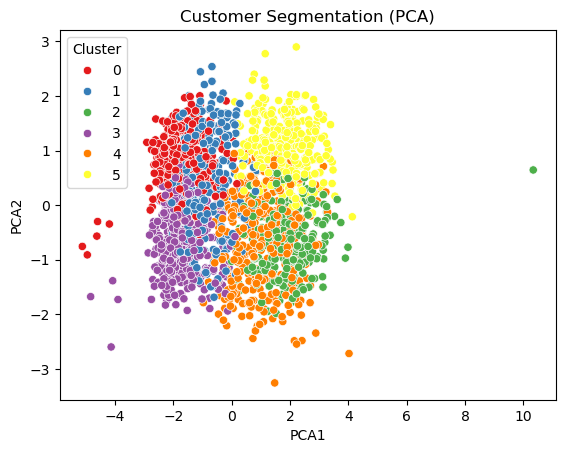

In [119]:
sns.scatterplot(x = 'PCA1',y='PCA2',hue = 'Cluster',data = df,palette = 'Set1')
plt.title('Customer Segmentation (PCA)')
plt.show()

In [120]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,49.182561,32833.174387,120.602180,2.362398,3.204360,7.084469,77.005450
1,68.365931,43724.290221,173.201893,2.545741,4.047319,5.290221,51.375394
2,53.840125,77838.639498,1256.369906,4.818182,8.764890,2.802508,23.050157
3,48.703125,32456.959821,105.984375,2.140625,3.185268,6.674107,24.770089
4,59.719603,59414.454094,892.662531,8.019851,7.744417,6.503722,45.870968
5,59.975138,73354.323204,1210.240331,4.560773,8.430939,2.776243,74.941989


In [122]:
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler , 'scaler_2.pkl')

['scaler_2.pkl']